In [37]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import yaml


In [88]:
boltz_results = Path("/Users/thomasbush/Downloads/boltz_attention/boltz_results_test_input_10/")
attention_results = boltz_results / "attention"
attention = np.load(attention_results / "test_input_10_attention.npz")
sequence = "/Users/thomasbush/Downloads/test_input_10.yaml"
msa_path = "/Users/thomasbush/Downloads/msa/A_protein_.a3m"

In [89]:
def parse_a3m(path: str | Path) -> list[str]:
    """Parse an A3M file and return a list of aligned sequences (no headers)."""
    sequences = []
    current = []
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if line.startswith(">"):
                if current:
                    sequences.append("".join(current))
                    current = []
            else:
                current.append(line)
    if current:
        sequences.append("".join(current))
    return sequences


def conservation_score(msa_path: str | Path) -> np.ndarray:
    """Compute per-residue conservation from an A3M MSA file.

    For each column aligned to the reference (first) sequence, computes the
    fraction of sequences that match the reference amino acid at that position.
    Gaps in the reference are skipped; lowercase insertions in other sequences
    are ignored.

    Parameters
    ----------
    msa_path : path to .a3m file

    Returns
    -------
    np.ndarray of shape (L,) with conservation scores in [0, 1] for each
    position in the reference sequence.
    """
    sequences = parse_a3m(msa_path)
    ref = sequences[0]

    # Reference columns are the uppercase/non-gap positions of the first sequence
    ref_cols = [i for i, c in enumerate(ref) if c.isupper() and c != "-"]
    L = len(ref_cols)

    # For each other sequence, extract only reference-aligned columns
    # (skip lowercase insertion characters in a3m format)
    aligned = []
    for seq in sequences[1:]:
        cols = []
        col_idx = 0
        for c in seq:
            if c == "-" or c.isupper():
                # This is an aligned column
                if col_idx in ref_cols:
                    cols.append(c.upper())
                col_idx += 1
            # lowercase = insertion relative to reference, skip
        if len(cols) == L:
            aligned.append(cols)

    if not aligned:
        return np.ones(L)

    ref_residues = [ref[i] for i in ref_cols]
    conservation = np.zeros(L)
    for j in range(L):
        matches = sum(1 for seq in aligned if seq[j] == ref_residues[j])
        conservation[j] = matches / len(aligned)

    return conservation


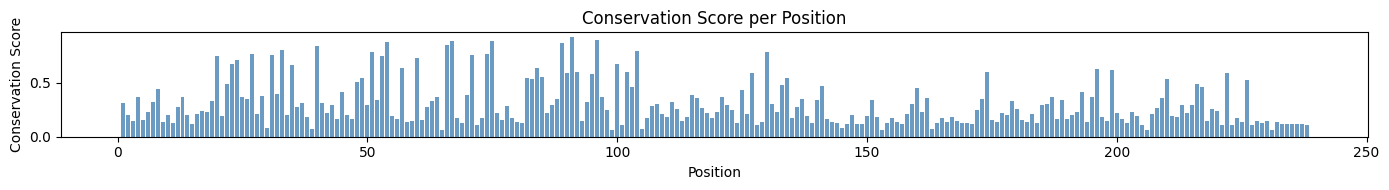

In [90]:
conservation_score_results = conservation_score(msa_path)
plt.figure(figsize=(14, 2))
plt.bar(range(1, len(conservation_score_results) + 1), conservation_score_results, color="steelblue", alpha=0.8)
plt.xlabel("Position")
plt.ylabel("Conservation Score")
plt.title("Conservation Score per Position")
plt.tight_layout()
plt.show()

In [91]:
# load sequence
if isinstance(sequence, (str, Path)) and Path(sequence).suffix in {".yml", ".yaml"}:
    with open(str(sequence), "r") as f:
        sequence_data = yaml.safe_load(f)
else:
    # If sequence is already loaded as a dict or passed incorrectly as a dict-string
    if isinstance(sequence, dict):
        sequence_data = sequence
    elif isinstance(sequence, str):
        try:
            sequence_data = yaml.safe_load(sequence)
        except Exception:
            raise ValueError("Provided sequence variable is a string, but not a valid path or YAML string.")
    else:
        raise ValueError("Cannot interpret `sequence` as a file path or YAML dict/string.")

sequences = sequence_data["sequences"]
print(sequences)
sequence = sequences[0]["protein"]["sequence"]

[{'protein': {'id': 'A', 'sequence': 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK', 'msa': '/n/netscratch/kempner_bsabatini_lab/Lab/Boltz-project/original_structures/sequences/test_input_10/msa/A_protein_.a3m'}}]


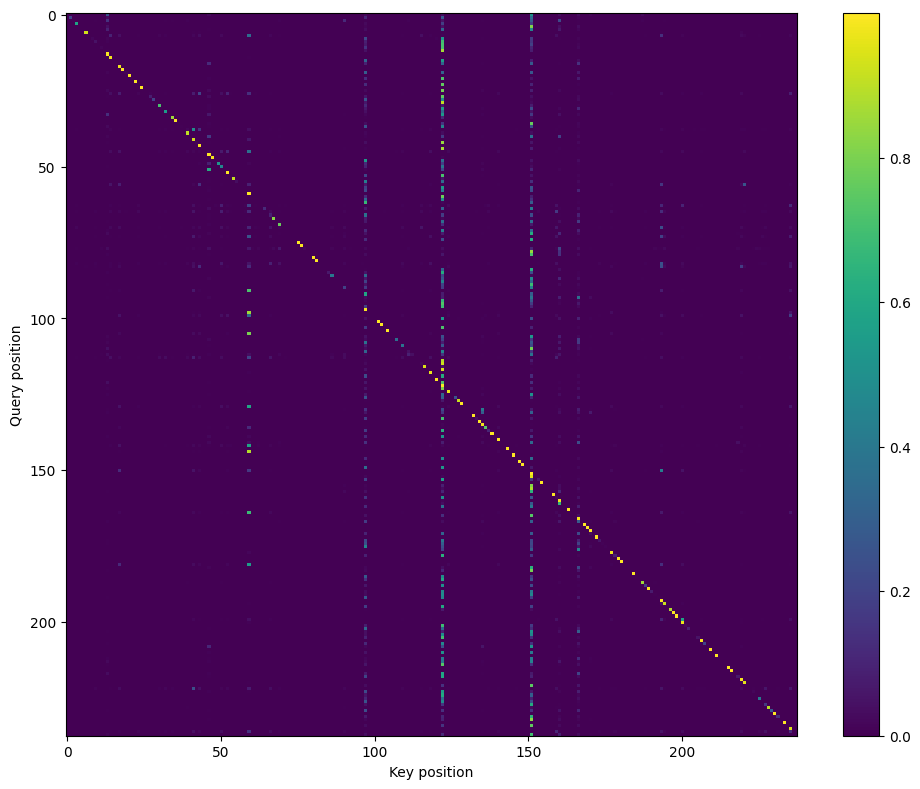

In [102]:
att = attention["pairformer_layer_47"]  # (1, 16, 238, 238)
att_np = att.squeeze(0)[-1]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(att_np, cmap="viridis", aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xlabel("Key position"); ax.set_ylabel("Query position")
plt.tight_layout(); plt.show()

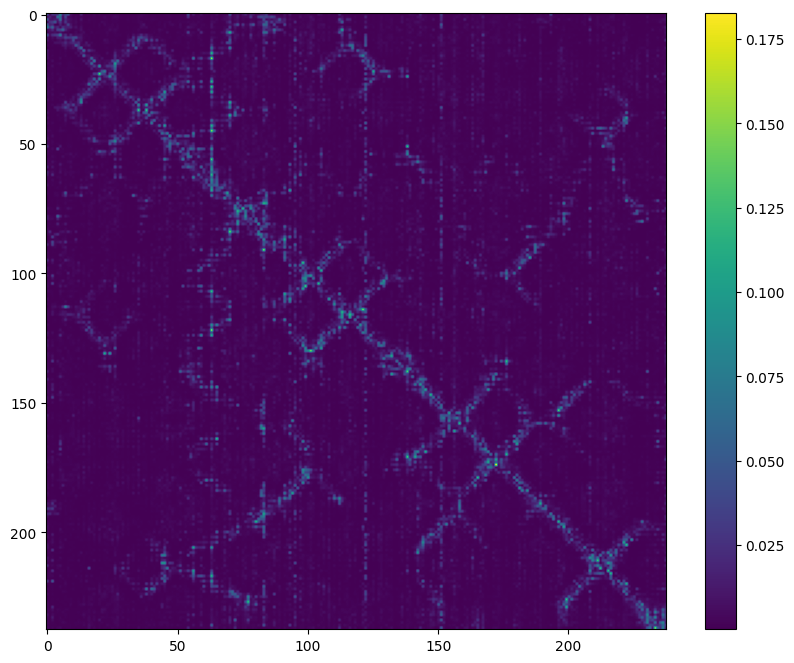

In [100]:
att_np = attention["pairformer_layer_47"].squeeze(0).mean(0) # (238, 238)
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(att_np, cmap="viridis", aspect="auto")
plt.colorbar(ax.images[0], ax=ax)
plt.show()

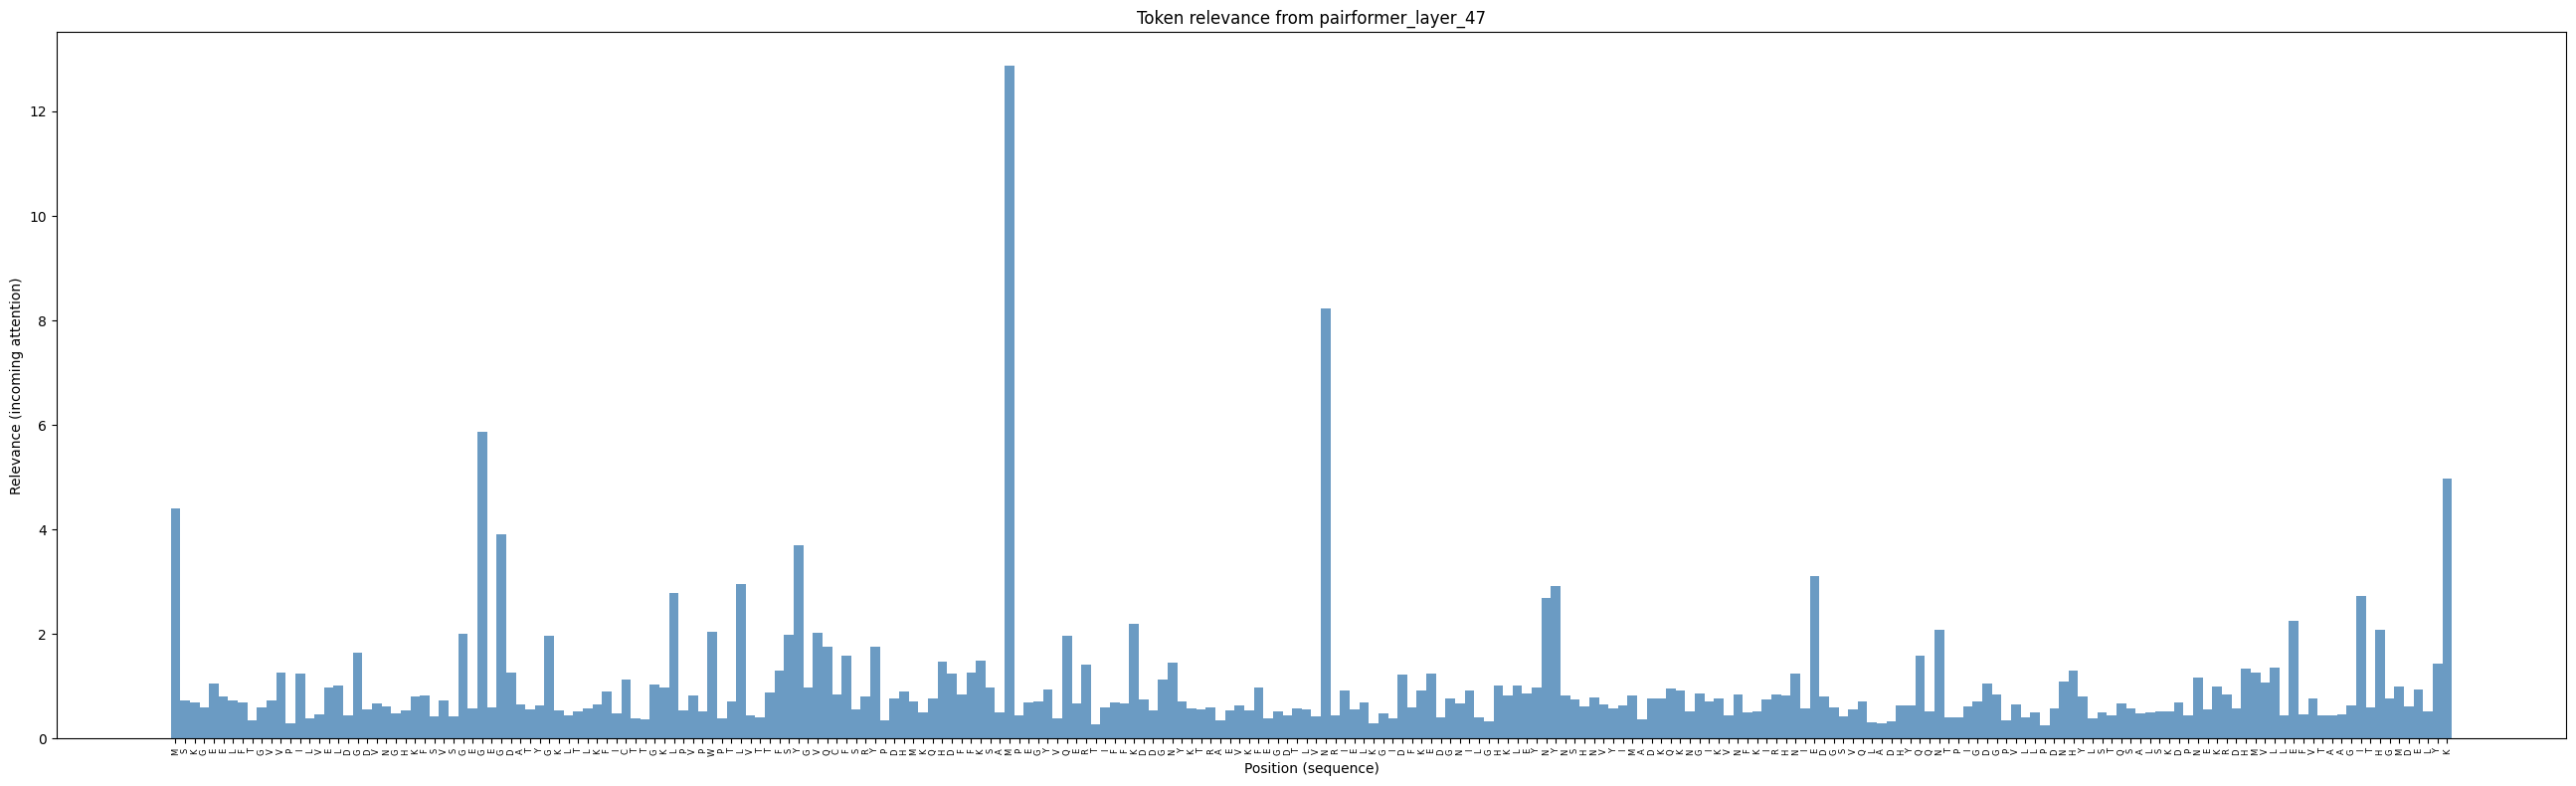

In [103]:
att = attention["pairformer_layer_23"]
att_np = att.squeeze(0).mean(0)  # (238, 238)
relevance = att_np.sum(axis=0)  # (238,)

fig, ax = plt.subplots(figsize=(26, 8))
x = np.arange(len(relevance))
ax.bar(x, relevance, width=1, color="steelblue", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(list(sequence), fontsize=6)
ax.set_xlabel("Position (sequence)")
ax.set_ylabel("Relevance (incoming attention)")
ax.set_title("Token relevance from pairformer_layer_47")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

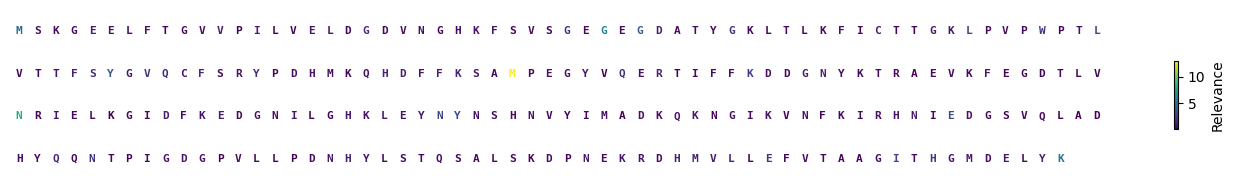

In [ ]:
import matplotlib as mpl

chars_per_row = 60  # tune for readability
L = len(sequence)
n_rows = (L + chars_per_row - 1) // chars_per_row

norm = mpl.colors.Normalize(vmin=relevance.min(), vmax=relevance.max())
cmap = mpl.cm.viridis

fig, ax = plt.subplots(figsize=(14, max(2, n_rows * 0.5)))
ax.set_xlim(-0.5, min(chars_per_row, L) - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)  # row 0 at top
ax.axis("off")

for i, aa in enumerate(sequence):
    row, col = divmod(i, chars_per_row)
    color = cmap(norm(relevance[i]))
    ax.text(col, row, aa, ha="center", va="center", fontsize=8, fontfamily="monospace",
            color=color, fontweight="bold")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.4, aspect=20, label="Relevance")
plt.tight_layout()
plt.show()